# Assignment 3 — Pinecone Cloud Vector Database
This notebook builds a Pinecone-based semantic search workflow and compares it with local FAISS retrieval on the same corpus and query.


In [1]:
%pip install -q pinecone-client pinecone sentence-transformers faiss-cpu pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import time
import uuid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss
from sentence_transformers import SentenceTransformer
from pinecone import Pinecone, ServerlessSpec


c:\Users\rahul\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Set API key and initialize Pinecone
You can either hardcode the key temporarily for testing or store it in your environment for safer use.


In [6]:
PINECONE_API_KEY = os.getenv('PINECONE_API_KEY', 'pcsk_7DW7ZY_7hu3YrMhZKN1YZ4SmVzJrSnyLFeG89FmQwVzpQ2De6Z9NL73PAiBdXfaUJxVAUS')
INDEX_NAME = 'student-demo'

if PINECONE_API_KEY == 'PASTE_YOUR_PINECONE_API_KEY_HERE':
    raise ValueError('Please set your Pinecone API key before running this notebook.')

pc = Pinecone(api_key=PINECONE_API_KEY)
print('Pinecone client initialized successfully.')


Pinecone client initialized successfully.


## 2. Build a corpus of at least 50 documents
This assignment uses 50 short AI-related documents across water monitoring, NLP, computer vision, forecasting, and infrastructure topics.


In [8]:
documents = [
    'AI models detect oil spills in oceans using satellite imagery and spectral signatures.',
    'Machine learning estimates water quality from pH, turbidity, and dissolved oxygen sensor readings.',
    'Computer vision identifies floating plastic waste in rivers from drone footage.',
    'Deep learning predicts harmful algal blooms from nutrient and temperature measurements.',
    'NLP extracts environmental findings from scientific research papers about water systems.',
    'AI forecasting models estimate flood risk from rainfall, elevation, and land-use patterns.',
    'Anomaly detection identifies leaks in city water pipelines from pressure signals.',
    'Remote sensing models monitor wetland health and freshwater ecosystem changes over time.',
    'AI helps optimize wastewater treatment by adjusting aeration and dosing automatically.',
    'Semantic search retrieves environmental reports about pollution events faster than keyword search.',
    'Embeddings represent text as dense numeric vectors for semantic retrieval.',
    'FAISS supports fast local similarity search on vector embeddings.',
    'Pinecone provides a cloud-native managed vector database for production retrieval systems.',
    'Vector databases store embeddings and return semantically similar items for a query.',
    'Sentence transformers generate sentence-level embeddings for semantic matching tasks.',
    'AI can classify polluted water samples from sensor data in near real time.',
    'Computer vision detects foam, debris, and unusual color changes in canal monitoring images.',
    'Predictive models estimate groundwater contamination spread after industrial discharge.',
    'NLP-based question answering helps agencies search regulations about water safety.',
    'Retrieval-augmented generation combines search with language models for grounded answers.',
    'Hybrid search mixes semantic retrieval with keyword matching for better precision.',
    'Managed vector databases reduce the operational burden of scaling search infrastructure.',
    'Cloud search systems support remote access, persistence, and team collaboration.',
    'Index metadata can store document title, source, and topic for filtered search.',
    'ANN indexes trade perfect exactness for faster retrieval on large vector collections.',
    'HNSW graphs improve approximate nearest neighbor retrieval performance.',
    'IVF indexing partitions vectors into clusters for faster candidate search.',
    'Dense retrieval is useful when query wording differs from document wording.',
    'Keyword search works well for exact terms but often misses semantic similarity.',
    'Water infrastructure monitoring benefits from AI-based anomaly detection.',
    'Satellite-based monitoring helps track shoreline pollution over large regions.',
    'Sensor fusion combines multiple environmental signals for more accurate water predictions.',
    'Automatic document embeddings enable scalable similarity search applications.',
    'Cloud vector stores can handle updates without manually rebuilding a local index.',
    'Local FAISS indexes are often faster because they avoid network round trips.',
    'Pinecone can be easier to deploy for multi-user applications than self-managed FAISS.',
    'Document metadata can restrict retrieval to only scientific or government sources.',
    'AI-powered search helps researchers explore large environmental literature collections.',
    'Embeddings capture semantic similarity even when documents use different vocabulary.',
    'A managed vector database usually provides persistence, availability, and scaling tools.',
    'Real-time semantic search powers support assistants, enterprise search, and RAG systems.',
    'Monitoring pollution incidents requires integrating text reports with sensor observations.',
    'AI systems can prioritize water contamination alerts based on predicted risk.',
    'Top-k retrieval returns the most similar documents for a given embedding query.',
    'Semantic matching can retrieve flood documents even if the query mentions overflow risk.',
    'Water quality dashboards can use vector search to surface related incident histories.',
    'Cloud indexes support persistence across notebook restarts and different machines.',
    'FAISS is strong for experiments on a single machine with direct control of the index.',
    'Pinecone is useful when you need managed infrastructure and remote access.',
    'Comparing FAISS and Pinecone helps understand trade-offs between speed and operational simplicity.',
    'AI helps identify pollution patterns by comparing new incidents with historical records.'
]

metadatas = [
    {"title": f"Doc {i+1}", "source": "assignment", "topic": "ai-water"}
    for i in range(len(documents))
]

print('Total documents:', len(documents))


Total documents: 51


## 3. Create embeddings
The same embedding model is used for Pinecone and FAISS so the result comparison is meaningful.


In [9]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(documents, convert_to_numpy=True).astype('float32')
dimension = embeddings.shape[1]
print('Embeddings shape:', embeddings.shape)


Embeddings shape: (51, 384)


## 4. Create Pinecone index
This uses a serverless index named `student-demo`. If it already exists, the notebook reuses it.


In [10]:
existing_indexes = [idx['name'] if isinstance(idx, dict) else idx.name for idx in pc.list_indexes()]

if INDEX_NAME not in existing_indexes:
    pc.create_index(
        name=INDEX_NAME,
        dimension=dimension,
        metric='cosine',
        spec=ServerlessSpec(cloud='aws', region='us-east-1')
    )
    print(f'Created index: {INDEX_NAME}')
else:
    print(f'Index already exists: {INDEX_NAME}')

while not pc.describe_index(INDEX_NAME).status['ready']:
    time.sleep(1)

index = pc.Index(INDEX_NAME)
print('Index ready.')


Created index: student-demo
Index ready.


## 5. Upsert at least 50 documents into Pinecone
Each vector includes an ID, embedding, and metadata.


In [11]:
vectors = []
for i, (doc, emb, meta) in enumerate(zip(documents, embeddings, metadatas)):
    vectors.append({
        'id': f'doc-{i+1}',
        'values': emb.tolist(),
        'metadata': {**meta, 'text': doc}
    })

start_upsert = time.perf_counter()
index.upsert(vectors=vectors)
pinecone_upsert_time = time.perf_counter() - start_upsert

print(f'Upserted {len(vectors)} vectors in {pinecone_upsert_time:.4f} seconds')


Upserted 51 vectors in 1.9782 seconds


## 6. Build a comparable FAISS index
This provides a local baseline for comparison using the same embeddings.


In [12]:
faiss.normalize_L2(embeddings)
faiss_index = faiss.IndexFlatIP(dimension)
faiss_index.add(embeddings)
print('FAISS vectors in index:', faiss_index.ntotal)


FAISS vectors in index: 51


## 7. Query Pinecone and FAISS with the same question
This compares top-3 results and approximate query times.


In [13]:
query = 'How does AI detect pollution in water bodies?'
query_embedding = model.encode([query], convert_to_numpy=True).astype('float32')
faiss.normalize_L2(query_embedding)

start_pinecone = time.perf_counter()
pinecone_results = index.query(
    vector=query_embedding[0].tolist(),
    top_k=3,
    include_metadata=True
)
pinecone_query_time = time.perf_counter() - start_pinecone

start_faiss = time.perf_counter()
faiss_scores, faiss_indices = faiss_index.search(query_embedding, 3)
faiss_query_time = time.perf_counter() - start_faiss

print('Query:', query)
print(f'Pinecone query time: {pinecone_query_time:.6f} sec')
print(f'FAISS query time:    {faiss_query_time:.6f} sec')


Query: How does AI detect pollution in water bodies?
Pinecone query time: 0.677466 sec
FAISS query time:    0.003144 sec


In [15]:
print('--- Pinecone Top 3 ---')
for rank, match in enumerate(pinecone_results['matches'], start=1):
    print(f"Rank {rank} | ID: {match['id']} | Score: {match['score']:.4f}")
    print(match['metadata']['text'])
    print()

print('--- FAISS Top 3 ---')
for rank, (idx, score) in enumerate(zip(faiss_indices[0], faiss_scores[0]), start=1):
    print(f'Rank {rank} | ID: doc-{idx+1} | Score: {score:.4f}')
    print(documents[idx])
    print()


--- Pinecone Top 3 ---
Rank 1 | ID: doc-16 | Score: 0.7182
AI can classify polluted water samples from sensor data in near real time.

Rank 2 | ID: doc-51 | Score: 0.6431
AI helps identify pollution patterns by comparing new incidents with historical records.

Rank 3 | ID: doc-43 | Score: 0.6283
AI systems can prioritize water contamination alerts based on predicted risk.

--- FAISS Top 3 ---
Rank 1 | ID: doc-16 | Score: 0.7186
AI can classify polluted water samples from sensor data in near real time.

Rank 2 | ID: doc-51 | Score: 0.6432
AI helps identify pollution patterns by comparing new incidents with historical records.

Rank 3 | ID: doc-43 | Score: 0.6284
AI systems can prioritize water contamination alerts based on predicted risk.



## 8. Comparison table
This creates a simple assignment-ready comparison of Pinecone and FAISS.


In [16]:
comparison_df = pd.DataFrame([
    {
        'System': 'FAISS',
        'Type': 'Local vector index',
        'Setup': 'Install library and build index locally',
        'Ease': 'Good for experiments, more manual for deployment',
        'Query Time (sec)': faiss_query_time
    },
    {
        'System': 'Pinecone',
        'Type': 'Managed cloud vector database',
        'Setup': 'Create account, API key, create cloud index',
        'Ease': 'Easier for production-style deployment and persistence',
        'Query Time (sec)': pinecone_query_time
    }
])
comparison_df


,System,Type,Setup,Ease,Query Time (sec)
0,FAISS,Local vector index,Install library and build index locally,"Good for experiments, more manual for deployment",0.003144
1,Pinecone,Managed cloud vector database,"Create account, API key, create cloud index",Easier for production-style deployment and per...,0.677466


## 9. Visualize latency
Use this chart and the printed results as screenshots for your deliverable.


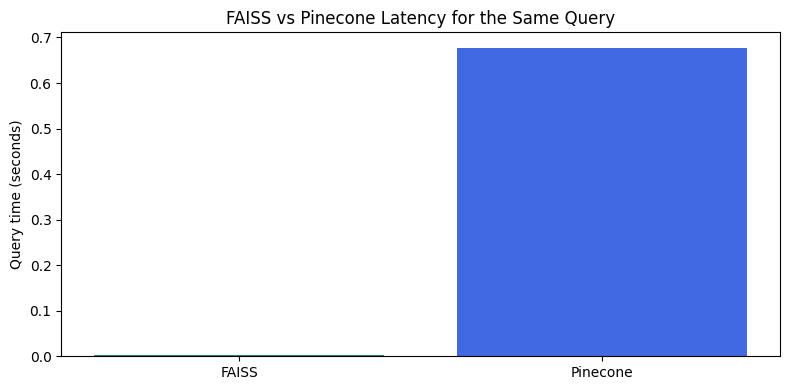

In [17]:
plt.figure(figsize=(8, 4))
plt.bar(['FAISS', 'Pinecone'], [faiss_query_time, pinecone_query_time], color=['seagreen', 'royalblue'])
plt.ylabel('Query time (seconds)')
plt.title('FAISS vs Pinecone Latency for the Same Query')
plt.tight_layout()
plt.show()


## Reflection answers
- **How does latency compare to FAISS?** FAISS is often faster locally because it avoids network round trips, while Pinecone adds network and service overhead.
- **What advantages does a managed vector DB provide?** Pinecone provides managed infrastructure, persistence, remote access, scaling, and easier production deployment.
- **Observed retrieval quality:** Because both systems use the same embeddings, the top results are often similar, though exact ranking may differ slightly.


## Optional extensions
You can reuse the same notebook structure for Weaviate, Milvus, or Qdrant by changing the client setup and indexing/query cells while keeping the same corpus and query set.
